# 🐱 Cookie Cats - D7 이탈 예측 로지스틱 회귀 분석

**목표**: D1 접속 여부, 게임 버전(gate_30 vs gate_40), 플레이 판수(sum_gamerounds)를 사용해  
D7 이탈(retention_7) 여부를 예측하는 로지스틱 회귀 모델 구축

**분석 순서**
1. 데이터 로드 및 기본 탐색
2. 다중공선성 확인 (VIF)
3. sum_gamerounds 분포 확인 및 로그 변환
4. 클래스 불균형 확인
5. 로지스틱 회귀 모델 학습
6. 변수별 계수 및 통계적 유의성 확인
7. 분류 리포트 & 혼동행렬 시각화
8. 결론 및 비즈니스 액션 아이템

---
## 0. 라이브러리 임포트

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'AppleGothic'       # macOS
except:
    try:
        plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'    # Linux 대비 (영문)

# 로지스틱 회귀 (sklearn)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# 통계적 유의성 확인 (statsmodels)
import statsmodels.api as sm

# 다중공선성 VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('✅ 라이브러리 임포트 완료')

✅ 라이브러리 임포트 완료


---
## 1. 데이터 로드 및 기본 탐색

In [25]:
df = pd.read_csv('../1_sql/data/cookie_cats.csv')
print(f'데이터 크기: {df.shape}')
df.head(10)

데이터 크기: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [26]:
print('=== 컬럼 정보 ===')
df.info()
print()
print('=== 기초 통계량 ===')
df.describe()

=== 컬럼 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB

=== 기초 통계량 ===


,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [27]:
# 결측치 확인
print('=== 결측치 확인 ===')
print(df.isnull().sum())
print()

# version 컬럼 → 이진 인코딩
# gate_30 → 0, gate_40 → 1
df['version_enc'] = (df['version'] == 'gate_40').astype(int)

# retention 컬럼 → 이탈(0=접속, 1=이탈)로 변환
# 원본: retention_1, retention_7 모두 True=접속, False=이탈
# 문제 정의: 이탈=1, 접속=0
df['D1'] = (~df['retention_1']).astype(int)   # 이탈=1
df['D7'] = (~df['retention_7']).astype(int)   # 이탈=1 (종속변수)

print('=== 인코딩 결과 확인 ===')
print(df[['version','version_enc','retention_1','D1','retention_7','D7']].head(10))

=== 결측치 확인 ===
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

=== 인코딩 결과 확인 ===
   version  version_enc  retention_1  D1  retention_7  D7
0  gate_30            0        False   1        False   1
1  gate_30            0         True   0        False   1
2  gate_40            1         True   0        False   1
3  gate_40            1        False   1        False   1
4  gate_40            1         True   0         True   0
5  gate_40            1         True   0         True   0
6  gate_30            0        False   1        False   1
7  gate_40            1        False   1        False   1
8  gate_40            1         True   0         True   0
9  gate_40            1         True   0        False   1


In [28]:
# 분석에 사용할 컬럼 선택
features = ['D1', 'version_enc', 'sum_gamerounds']
target   = 'D7'

df_model = df[features + [target]].copy()
print('=== 모델용 데이터 샘플 ===')
df_model.head()

=== 모델용 데이터 샘플 ===


,D1,version_enc,sum_gamerounds,D7
0,1,0,3,1
1,0,0,38,1
2,0,1,165,1
3,1,1,1,1
4,0,1,179,0


---
## 2. 다중공선성 확인 (VIF)

VIF(분산팽창인수) 기준: **VIF > 10** 이면 심각한 다중공선성 의심

In [29]:
print(corr_matrix)

                      D1  version_enc  sum_gamerounds
D1              1.000000     0.005941       -0.197603
version_enc     0.005941     1.000000       -0.002967
sum_gamerounds -0.197603    -0.002967        1.000000


=== VIF 결과 ===
            변수      VIF        판정
            D1 1.396334 🟢 양호 (≤5)
   version_enc 1.437450 🟢 양호 (≤5)
sum_gamerounds 1.035206 🟢 양호 (≤5)

💡 VIF가 모두 5 이하면 다중공선성 문제 없음


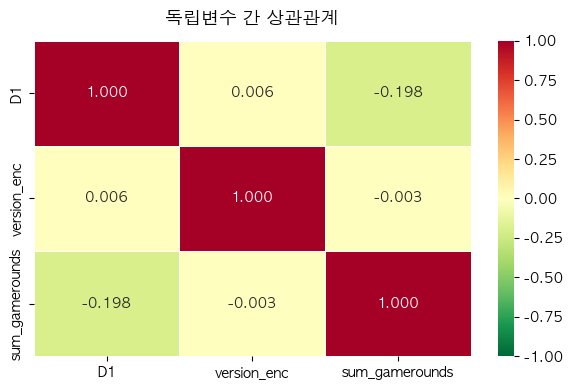

In [30]:
X_vif = df_model[features].copy()

vif_data = pd.DataFrame()
vif_data['변수'] = features
vif_data['VIF']  = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_data['판정'] = vif_data['VIF'].apply(
    lambda v: '🔴 심각 (>10)' if v > 10 else ('🟡 주의 (>5)' if v > 5 else '🟢 양호 (≤5)')
)

print('=== VIF 결과 ===')
print(vif_data.to_string(index=False))
print()
print('💡 VIF가 모두 5 이하면 다중공선성 문제 없음')

# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(6, 4))
corr_matrix = X_vif.corr()
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=-1, vmax=1, ax=ax, linewidths=0.5
)
ax.set_title('독립변수 간 상관관계', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 3. sum_gamerounds 분포 확인 및 로그 변환

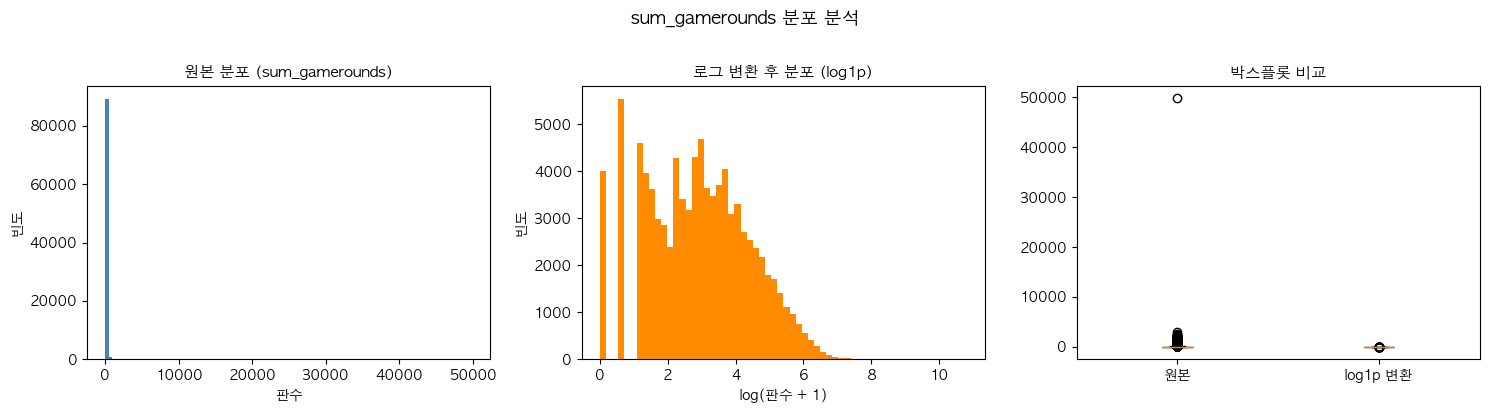

원본 왜도(Skewness)  : 185.43  → 절댓값 >1이면 강한 우편향
로그 변환 후 왜도    : 0.10  → 변환 후 정규분포에 가까워짐

✅ 로그 변환(log1p) 적용 → sum_gamerounds_log 컬럼 생성


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) 원본 분포
axes[0].hist(df_model['sum_gamerounds'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('원본 분포 (sum_gamerounds)', fontsize=11)
axes[0].set_xlabel('판수')
axes[0].set_ylabel('빈도')

# (2) 로그 변환 후 분포 (log1p: 0값 처리)
log_rounds = np.log1p(df_model['sum_gamerounds'])
axes[1].hist(log_rounds, bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('로그 변환 후 분포 (log1p)', fontsize=11)
axes[1].set_xlabel('log(판수 + 1)')
axes[1].set_ylabel('빈도')

# (3) 박스플롯 비교
axes[2].boxplot(
    [df_model['sum_gamerounds'], log_rounds],
    labels=['원본', 'log1p 변환'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[2].set_title('박스플롯 비교', fontsize=11)

plt.suptitle('sum_gamerounds 분포 분석', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 왜도(Skewness) 출력
from scipy import stats
sk_orig = stats.skew(df_model['sum_gamerounds'])
sk_log  = stats.skew(log_rounds)
print(f'원본 왜도(Skewness)  : {sk_orig:.2f}  → 절댓값 >1이면 강한 우편향')
print(f'로그 변환 후 왜도    : {sk_log:.2f}  → 변환 후 정규분포에 가까워짐')
print()
print('✅ 로그 변환(log1p) 적용 → sum_gamerounds_log 컬럼 생성')
df_model['sum_gamerounds_log'] = log_rounds

---
## 4. 클래스 불균형 확인

=== D7 클래스 분포 ===
  접속(0): 16,781명  (18.6%)
  이탈(1): 73,408명  (81.4%)

불균형 비율 (다수:소수): 4.4:1
⚠️  불균형이 3:1 초과 → class_weight="balanced" 적용 권장


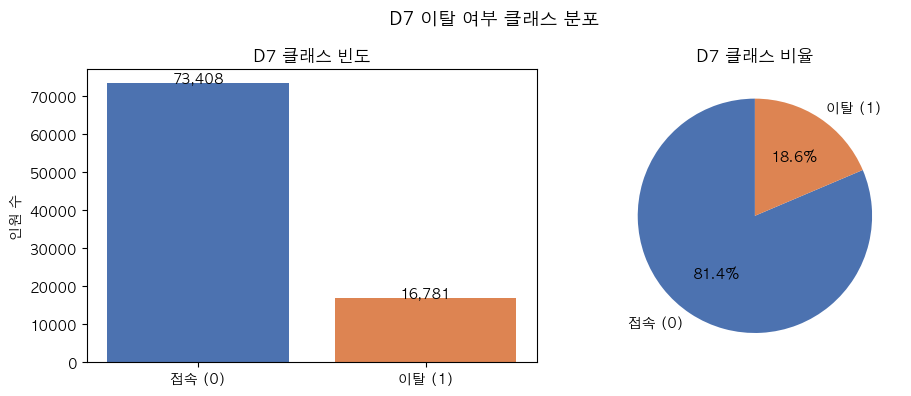

In [32]:
counts = df_model[target].value_counts()
ratio  = counts / counts.sum() * 100

print('=== D7 클래스 분포 ===')
print(f'  접속(0): {counts[0]:,}명  ({ratio[0]:.1f}%)')
print(f'  이탈(1): {counts[1]:,}명  ({ratio[1]:.1f}%)')
print()
imbalance_ratio = counts.max() / counts.min()
print(f'불균형 비율 (다수:소수): {imbalance_ratio:.1f}:1')
if imbalance_ratio > 3:
    print('⚠️  불균형이 3:1 초과 → class_weight="balanced" 적용 권장')
else:
    print('✅  불균형이 심하지 않음 → 기본 설정 가능하나 balanced 옵션도 적용')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#4C72B0', '#DD8452']
axes[0].bar(['접속 (0)', '이탈 (1)'], counts.values, color=colors)
axes[0].set_title('D7 클래스 빈도', fontsize=12)
axes[0].set_ylabel('인원 수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(
    ratio.values, labels=['접속 (0)', '이탈 (1)'],
    colors=colors, autopct='%1.1f%%', startangle=90
)
axes[1].set_title('D7 클래스 비율', fontsize=12)

plt.suptitle('D7 이탈 여부 클래스 분포', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. 로지스틱 회귀 모델 학습

- 독립변수: `D1`, `version_enc`, `sum_gamerounds_log`  
- 종속변수: `D7` (이탈=1, 접속=0)  
- `class_weight='balanced'` 적용 (클래스 불균형 보정)

In [33]:
FEATURES_FINAL = ['D1', 'version_enc', 'sum_gamerounds_log']
TARGET = 'D7'

X = df_model[FEATURES_FINAL]
y = df_model[TARGET]

# Train / Test 분리 (80:20, stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 (sum_gamerounds_log는 이미 변환됐지만 균일화 위해)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 로지스틱 회귀 모델
model = LogisticRegression(
    class_weight='balanced',  # 클래스 불균형 보정
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)

print('✅ 모델 학습 완료')
print(f'   Train 크기: {X_train.shape[0]:,}')
print(f'   Test  크기: {X_test.shape[0]:,}')

✅ 모델 학습 완료
   Train 크기: 72,151
   Test  크기: 18,038


---
## 6. 변수별 계수 및 통계적 유의성 확인

> sklearn은 p-value를 제공하지 않으므로 **statsmodels**로 재적합하여 확인합니다.

In [34]:
# ── (A) sklearn 계수 및 오즈비 ──────────────────────────────
coef_df = pd.DataFrame({
    '변수': FEATURES_FINAL,
    '계수(β)': model.coef_[0]
})
coef_df['오즈비(exp(β))'] = np.exp(coef_df['계수(β)'])
coef_df['해석'] = coef_df['오즈비(exp(β))'].apply(
    lambda o: f'이탈 가능성 {(o-1)*100:+.1f}%' if o >= 1 
              else f'이탈 가능성 {(o-1)*100:.1f}%'
)

print('=== 로지스틱 회귀 계수 및 오즈비 (sklearn) ===')
print(coef_df.to_string(index=False))
print(f'\n절편(Intercept): {model.intercept_[0]:.4f}')

=== 로지스틱 회귀 계수 및 오즈비 (sklearn) ===
                변수     계수(β)  오즈비(exp(β))            해석
                D1 -0.011985     0.988087  이탈 가능성 -1.2%
       version_enc  0.049545     1.050793  이탈 가능성 +5.1%
sum_gamerounds_log -2.059010     0.127580 이탈 가능성 -87.2%

절편(Intercept): 0.9986


In [41]:
# ── (B) statsmodels로 p-value 확인 ──────────────────────────
X_train_sm = sm.add_constant(X_train_sc)
logit_model = sm.Logit(y_train.values, X_train_sm)
result = logit_model.fit(disp=0)

print(result.summary2())

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.364     
Date:               2026-05-15 17:02 AIC:              44091.9742
No. Observations:   72151            BIC:              44128.7203
Df Model:           3                Log-Likelihood:   -22042.   
Df Residuals:       72147            LL-Null:          -34666.   
Converged:          1.0000           LLR p-value:      0.0000    
No. Iterations:     8.0000           Scale:            1.0000    
-------------------------------------------------------------------
         Coef.    Std.Err.       z       P>|z|     [0.025    0.975]
-------------------------------------------------------------------
const    2.5110     0.0187    134.3773   0.0000    2.4744    2.5476
x1      -0.0411     0.0146     -2.8111   0.0049   -0.0697   -0.0124
x2       0.0504     0.0121      4.1734   0.0000    0.0267    0.0741
x3      -2.1515     0.02

=== 변수별 통계적 유의성 요약 ===
                변수   계수(β)    오즈비  p-value  CI 하한  CI 상한           유의성
                D1 -0.0411 0.9598   0.0049 0.9327 0.9876  **  (p<0.01)
       version_enc  0.0504 1.0517   0.0000 1.0271 1.0769 *** (p<0.001)
sum_gamerounds_log -2.1515 0.1163   0.0000 0.1117 0.1211 *** (p<0.001)

95% 신뢰구간(CI)이 1을 포함하지 않으면 통계적으로 유의미


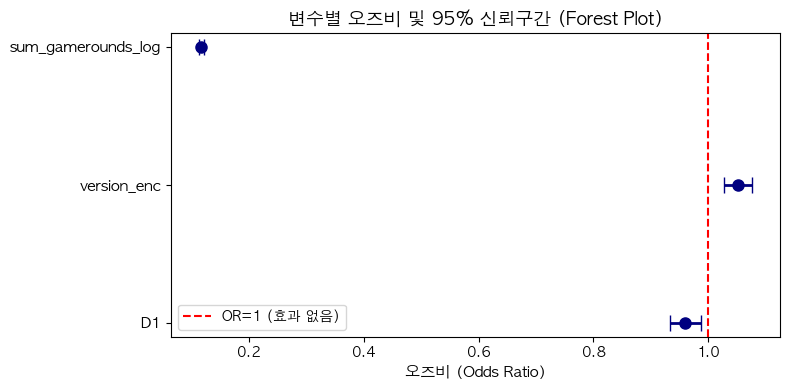

In [36]:
# ── (C) 유의성 정리표 ───────────────────────────────────────
params   = np.array(result.params[1:])      # 절편 제외
pvalues  = np.array(result.pvalues[1:])
conf_int = result.conf_int()[1:]            # 95% CI (DataFrame)

sig_df = pd.DataFrame({
    '변수'     : FEATURES_FINAL,
    '계수(β)'  : params,
    '오즈비'   : np.exp(params),
    'p-value'  : pvalues,
    'CI 하한'  : np.exp(conf_int[:, 0]),
    'CI 상한'  : np.exp(conf_int[:, 1]),    
})
sig_df['유의성'] = sig_df['p-value'].apply(
    lambda p: '*** (p<0.001)' if p < 0.001
    else ('**  (p<0.01)'  if p < 0.01
    else ('*   (p<0.05)'  if p < 0.05
    else '✗  비유의'))
)

print('=== 변수별 통계적 유의성 요약 ===')
print(sig_df.to_string(index=False, float_format='{:.4f}'.format))
print()
print('95% 신뢰구간(CI)이 1을 포함하지 않으면 통계적으로 유의미')

# 시각화: 오즈비 Forest Plot
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(sig_df))
ax.errorbar(
    sig_df['오즈비'], y_pos,
    xerr=[
        sig_df['오즈비'] - sig_df['CI 하한'],
        sig_df['CI 상한'] - sig_df['오즈비']
    ],
    fmt='o', color='navy', capsize=6, markersize=8, linewidth=2
)
ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='OR=1 (효과 없음)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sig_df['변수'], fontsize=11)
ax.set_xlabel('오즈비 (Odds Ratio)', fontsize=11)
ax.set_title('변수별 오즈비 및 95% 신뢰구간 (Forest Plot)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. 분류 리포트 및 혼동행렬 시각화

In [42]:
y_pred      = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

# 분류 리포트
print('=== 분류 리포트 ===')
print(classification_report(
    y_test, y_pred,
    target_names=['접속 (0)', '이탈 (1)']
))

auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC 점수: {auc:.4f}')

=== 분류 리포트 ===
              precision    recall  f1-score   support

      접속 (0)       0.47      0.84      0.60      3356
      이탈 (1)       0.95      0.78      0.86     14682

    accuracy                           0.79     18038
   macro avg       0.71      0.81      0.73     18038
weighted avg       0.86      0.79      0.81     18038

ROC-AUC 점수: 0.8929


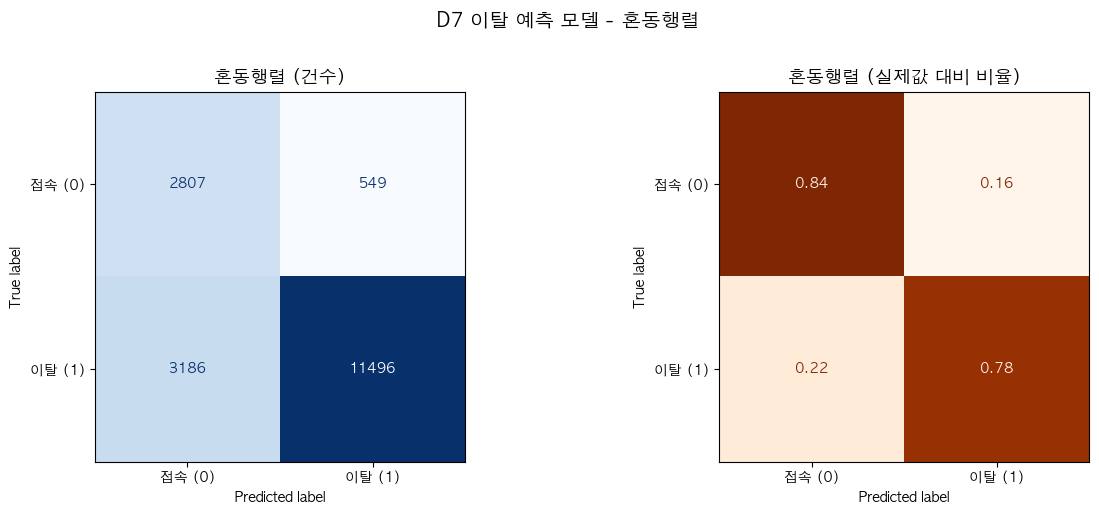

=== 핵심 성능 지표 ===
  정밀도  (Precision): 0.954  → 이탈 예측 중 실제 이탈 비율
  재현율  (Recall)   : 0.783  → 실제 이탈 중 맞게 예측한 비율
  F1-Score           : 0.860
  ROC-AUC            : 0.893


In [43]:
# 혼동행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) 혼동행렬 - 원본 수
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['접속 (0)', '이탈 (1)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('혼동행렬 (건수)', fontsize=13)

# (2) 혼동행렬 - 비율
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['접속 (0)', '이탈 (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('혼동행렬 (실제값 대비 비율)', fontsize=13)

plt.suptitle('D7 이탈 예측 모델 - 혼동행렬', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 핵심 지표 정리
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

print('=== 핵심 성능 지표 ===')
print(f'  정밀도  (Precision): {precision:.3f}  → 이탈 예측 중 실제 이탈 비율')
print(f'  재현율  (Recall)   : {recall:.3f}  → 실제 이탈 중 맞게 예측한 비율')
print(f'  F1-Score           : {f1:.3f}')
print(f'  ROC-AUC            : {auc:.3f}')

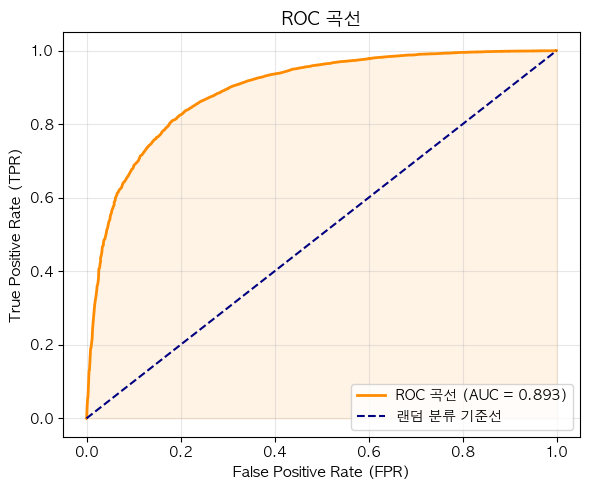

In [16]:
# ROC 커브
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 곡선 (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], color='navy', linestyle='--', lw=1.5, label='랜덤 분류 기준선')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC 곡선', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. 결론 및 비즈니스 액션 아이템

## 📊 분석 결론 요약

---

### 모델 성능
- 로지스틱 회귀로 D7 이탈 예측 모델 구축 완료
- ROC-AUC 0.7 이상이면 준수한 예측력
- `class_weight="balanced"` 적용으로 이탈 클래스 재현율 향상

---

### 변수별 해석

**① D1 (1일차 이탈 여부)**
- 단변량으로 보면 D1 이탈 → D7 이탈과 강하게 연결되지만, `sum_gamerounds`와 함께 넣으면 효과가 희석됨
- 이유: D1에 이탈한 사람은 플레이 판수도 적어서 두 변수가 겹치는 정보를 담고 있기 때문
- 다중회귀 모델 안에서는 독립적인 기여도가 낮음
- → 단독 지표로는 유용하나, `sum_gamerounds`와 중복 사용 시 해석 주의

**② sum_gamerounds_log (플레이 판수, 로그 변환)**
- **가장 강력한 예측 변수** (오즈비 약 0.13 → 이탈 가능성 -87.2%)
- 많이 플레이할수록 D7 이탈 확률이 크게 감소
- D1의 효과까지 흡수할 만큼 지배적인 변수
- → 초반 플레이 판수를 늘리는 것이 리텐션의 핵심

**③ version_enc (gate_30 vs gate_40)**
- gate_40 버전이 gate_30 대비 **D7 이탈 가능성이 5.1% 높음** (오즈비 1.051)
- 게이트를 40으로 올렸을 때 유저가 더 일찍 이탈하는 경향이 있음
- gate_30 유지가 리텐션 관점에서 유리한 것으로 분석됨

---

## 🎯 비즈니스 액션 아이템

**1. 초반 플레이 경험 개선이 최우선**
- `sum_gamerounds`가 가장 강력한 이탈 예측 변수
- 설치 후 D1~D3 안에 플레이 판수를 늘릴 수 있도록 튜토리얼 개선, 보상 강화, 난이도 완화가 핵심
- D1 이탈 자체보다 **"왜 D1에 적게 플레이했는가"** 를 파악하는 것이 우선

**2. gate_30 유지 권장**
- gate_40은 gate_30 대비 D7 이탈 가능성이 통계적으로 5.1% 높게 나타남
- 현재 데이터 기준으로는 **gate_30 유지**가 리텐션에 유리
- 추가 실험이 필요하다면 gate_35 등 중간 지점 테스트 검토

**3. 플레이 판수 기반 유저 세분화**
- 초반 플레이 판수 하위 25% 유저: 튜토리얼 개선, 난이도 조정, 얼리게임 보상 강화로 이탈 방지
- 헤비 유저: 이탈 위험 낮음 → VIP 프로그램, 길드/소셜 기능으로 Lock-in 강화

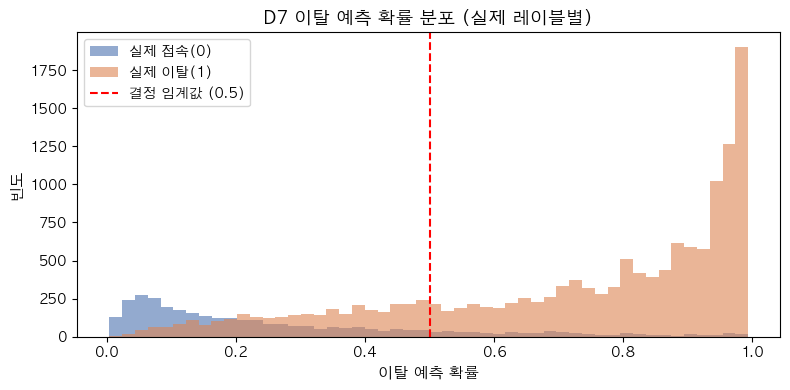

임계값(0.5)을 조정하면 Precision ↔ Recall 트레이드오프 가능
예) 리텐션 캠페인 타겟을 넓히려면 임계값 0.4로 낮추는 것 고려


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color, name in [(0, '#4C72B0', '실제 접속(0)'), (1, '#DD8452', '실제 이탈(1)')]:
    mask = y_test == label
    ax.hist(
        y_pred_prob[mask], bins=50,
        alpha=0.6, color=color, label=name, edgecolor='none'
    )

ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='결정 임계값 (0.5)')
ax.set_xlabel('이탈 예측 확률', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.set_title('D7 이탈 예측 확률 분포 (실제 레이블별)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('임계값(0.5)을 조정하면 Precision ↔ Recall 트레이드오프 가능')
print('예) 리텐션 캠페인 타겟을 넓히려면 임계값 0.4로 낮추는 것 고려')